In [1]:
%pip install feature-engine

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:

import re
from feature_engine.outliers import Winsorizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import seaborn as sb
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [3]:
df = pd.read_csv("creditcard.csv")

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
df = df.drop_duplicates(keep='first')

In [9]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [10]:
outlier_columns=['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class']

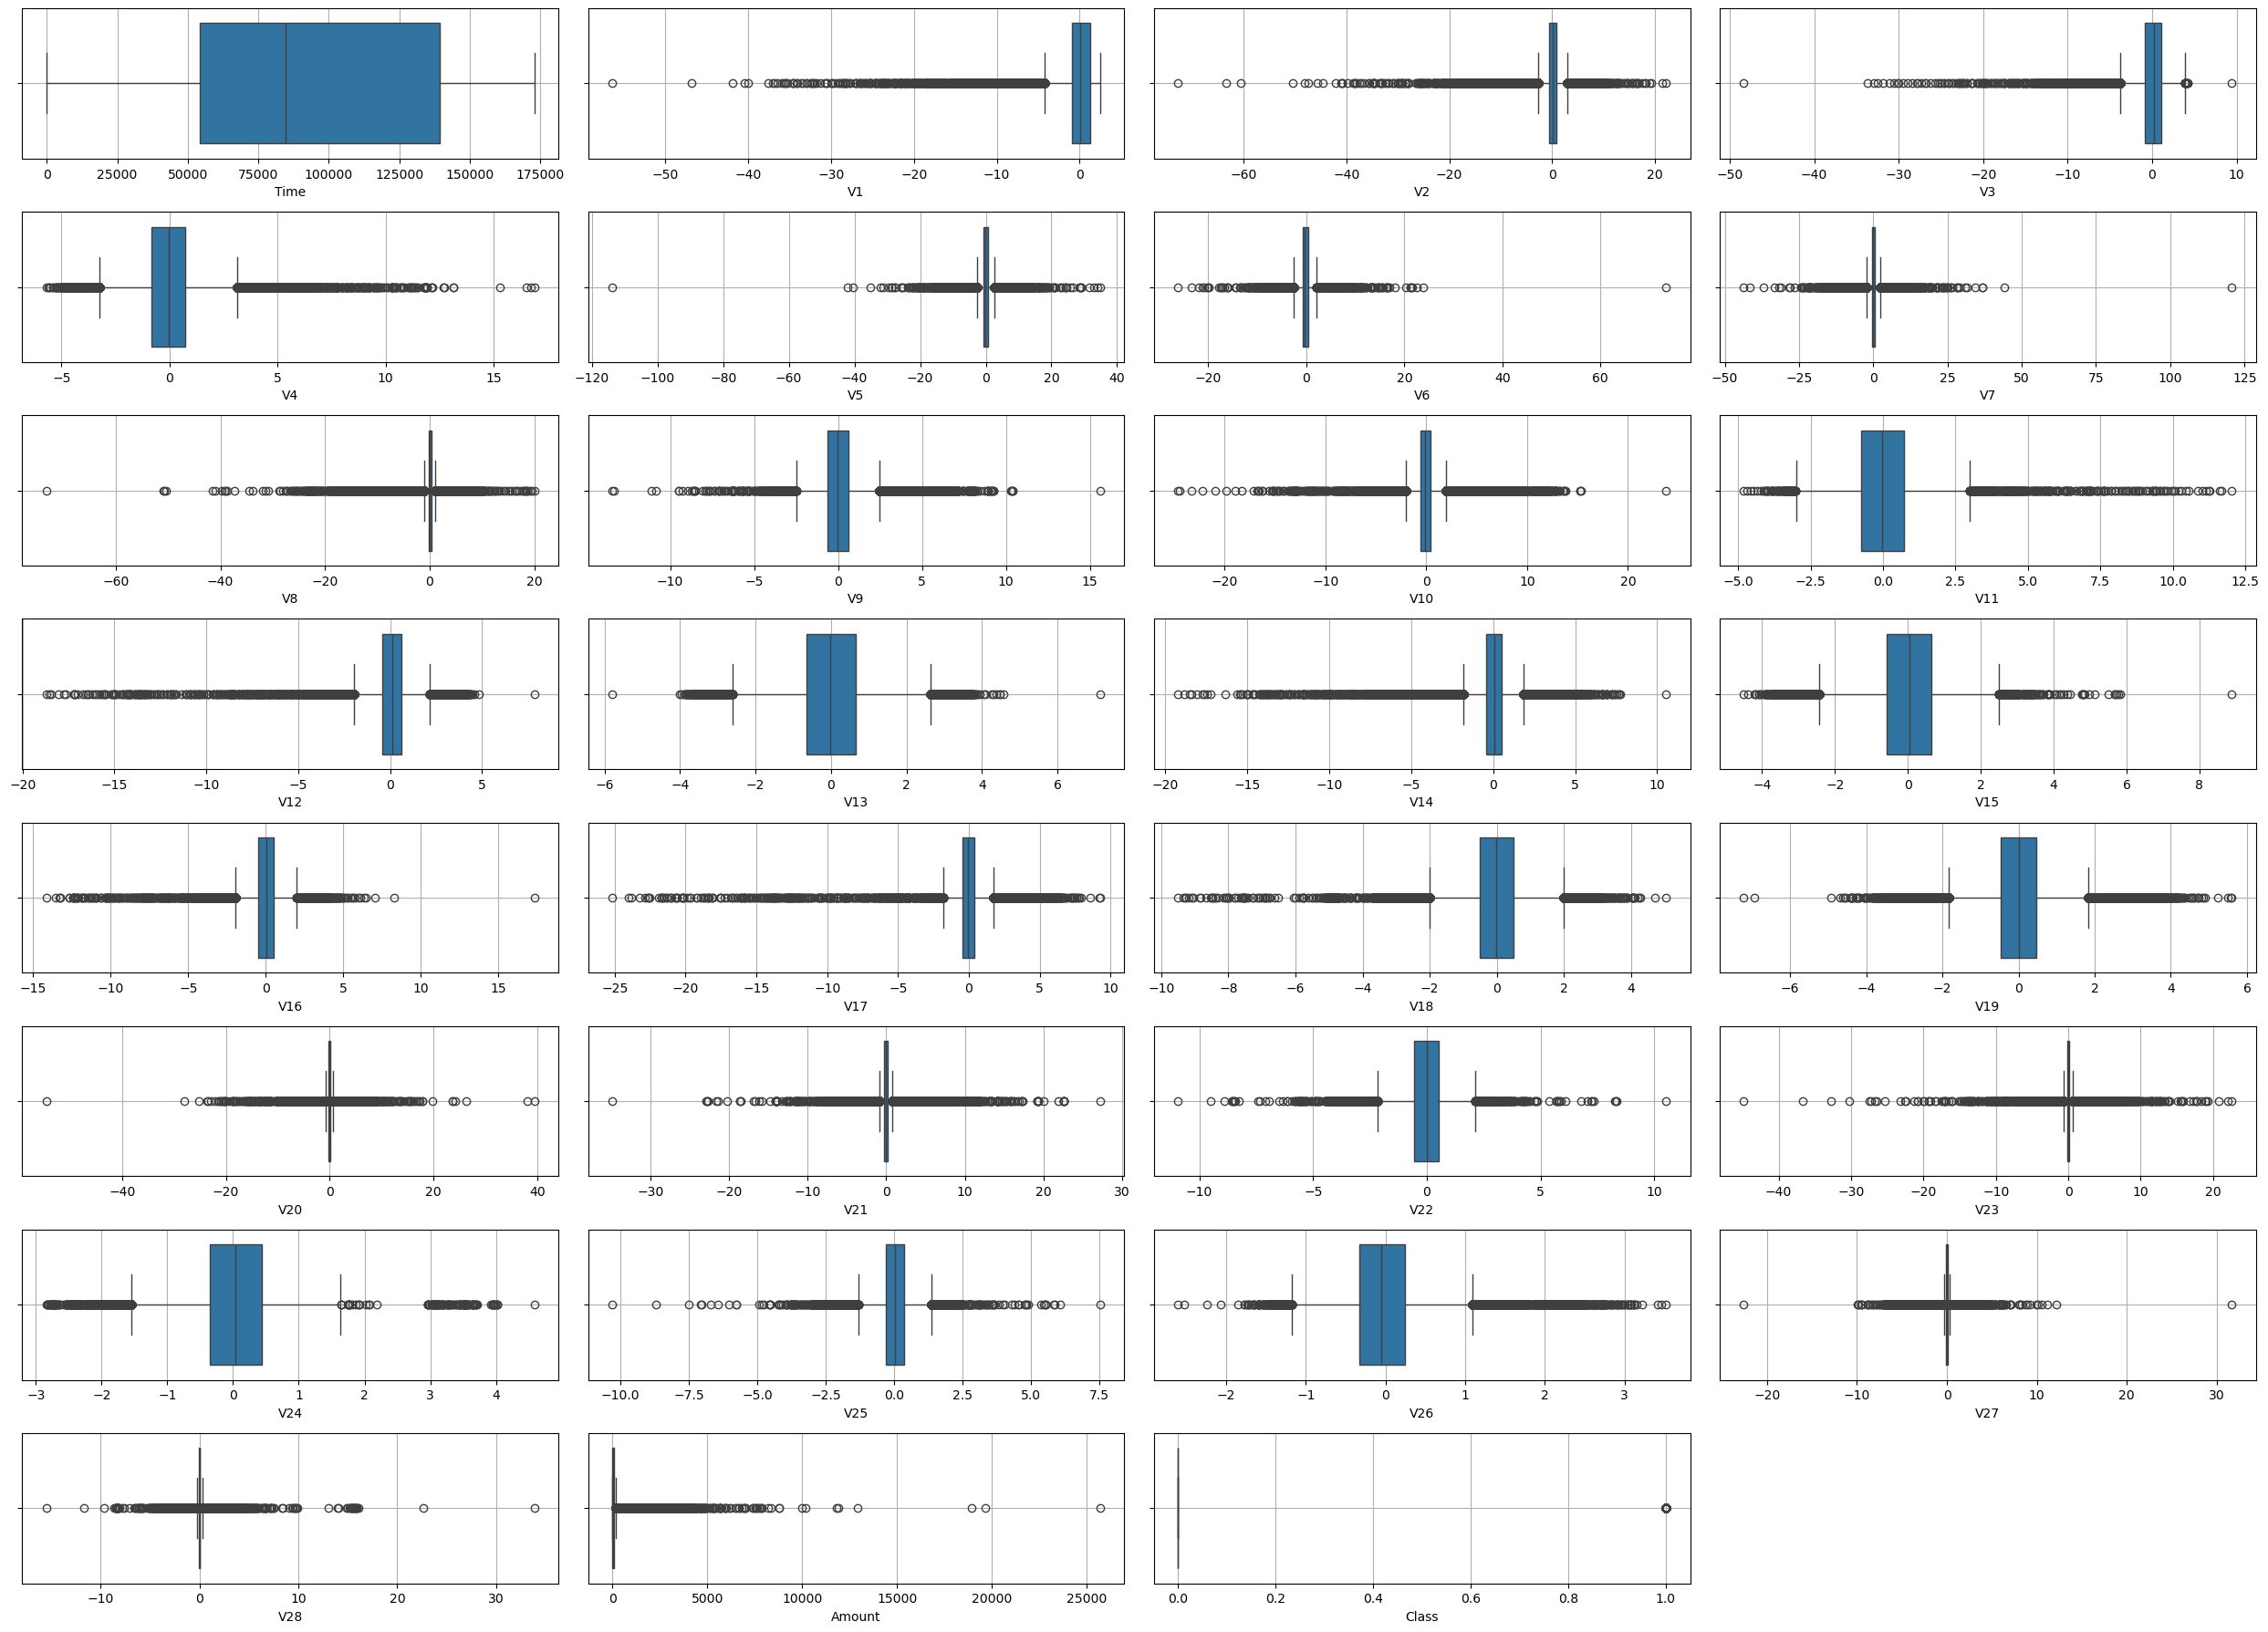

In [11]:
plt.figure(figsize=(25,18))

plt.subplot(8,4,1)
sb.boxplot(x=df['Time'])
plt.grid()

plt.subplot(8,4,2)
sb.boxplot(x=df['V1'])
plt.grid()

plt.subplot(8,4,3)
sb.boxplot(x=df['V2'])
plt.grid()

plt.subplot(8,4,4)
sb.boxplot(x=df['V3'])
plt.grid()

plt.subplot(8,4,5)
sb.boxplot(x=df['V4'])
plt.grid()

plt.subplot(8,4,6)
sb.boxplot(x=df['V5'])
plt.grid()

plt.subplot(8,4,7)
sb.boxplot(x=df['V6'])
plt.grid()

plt.subplot(8,4,8)
sb.boxplot(x=df['V7'])
plt.grid()

plt.subplot(8,4,9)
sb.boxplot(x=df['V8'])
plt.grid()

plt.subplot(8,4,10)
sb.boxplot(x=df['V9'])
plt.grid()

plt.subplot(8,4,11)
sb.boxplot(x=df['V10'])
plt.grid()

plt.subplot(8,4,12)
sb.boxplot(x=df['V11'])
plt.grid()

plt.subplot(8,4,13)
sb.boxplot(x=df['V12'])
plt.grid()

plt.subplot(8,4,14)
sb.boxplot(x=df['V13'])
plt.grid()

plt.subplot(8,4,15)
sb.boxplot(x=df['V14'])
plt.grid()

plt.subplot(8,4,16)
sb.boxplot(x=df['V15'])
plt.grid()

plt.subplot(8,4,17)
sb.boxplot(x=df['V16'])
plt.grid()

plt.subplot(8,4,18)
sb.boxplot(x=df['V17'])
plt.grid()

plt.subplot(8,4,19)
sb.boxplot(x=df['V18'])
plt.grid()

plt.subplot(8,4,20)
sb.boxplot(x=df['V19'])
plt.grid()

plt.subplot(8,4,21)
sb.boxplot(x=df['V20'])
plt.grid()

plt.subplot(8,4,22)
sb.boxplot(x=df['V21'])
plt.grid()

plt.subplot(8,4,23)
sb.boxplot(x=df['V22'])
plt.grid()

plt.subplot(8,4,24)
sb.boxplot(x=df['V23'])
plt.grid()

plt.subplot(8,4,25)
sb.boxplot(x=df['V24'])
plt.grid()

plt.subplot(8,4,26)
sb.boxplot(x=df['V25'])
plt.grid()

plt.subplot(8,4,27)
sb.boxplot(x=df['V26'])
plt.grid()

plt.subplot(8,4,28)
sb.boxplot(x=df['V27'])
plt.grid()

plt.subplot(8,4,29)
sb.boxplot(x=df['V28'])
plt.grid()

plt.subplot(8,4,30)
sb.boxplot(x=df['Amount'])
plt.grid()

plt.subplot(8,4,31)
sb.boxplot(x=df['Class'])
plt.grid()

plt.tight_layout()
plt.show()


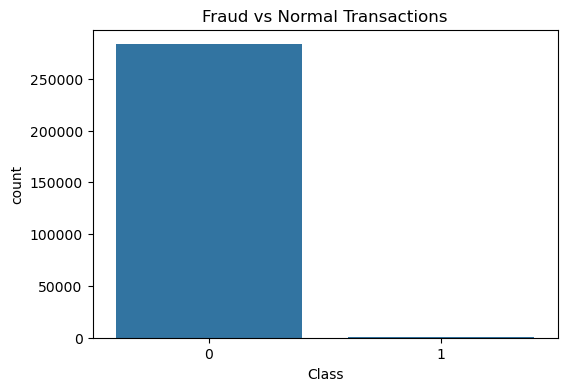

In [32]:
plt.figure(figsize=(6,4))
sb.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

In [33]:
fraud_percent = df['Class'].value_counts(normalize=True) * 100
print(fraud_percent)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [37]:
df.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class',
       'scaled_amount', 'scaled_time'],
      dtype='object')

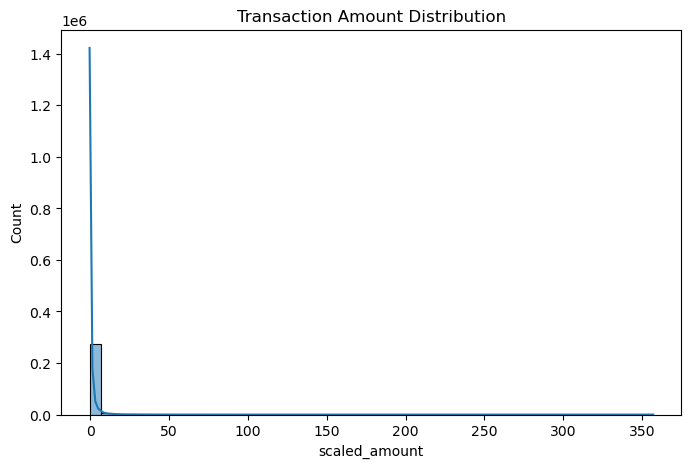

In [38]:
plt.figure(figsize=(8,5))
sb.histplot(df['scaled_amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

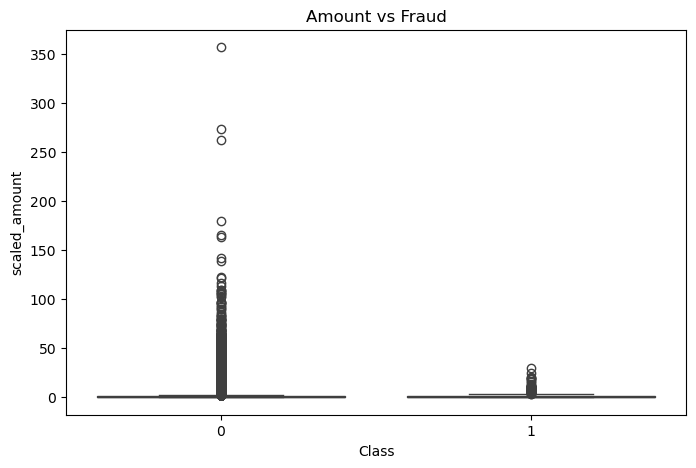

In [40]:
plt.figure(figsize=(8,5))
sb.boxplot(x='Class', y='scaled_amount', data=df)
plt.title("Amount vs Fraud")
plt.show()

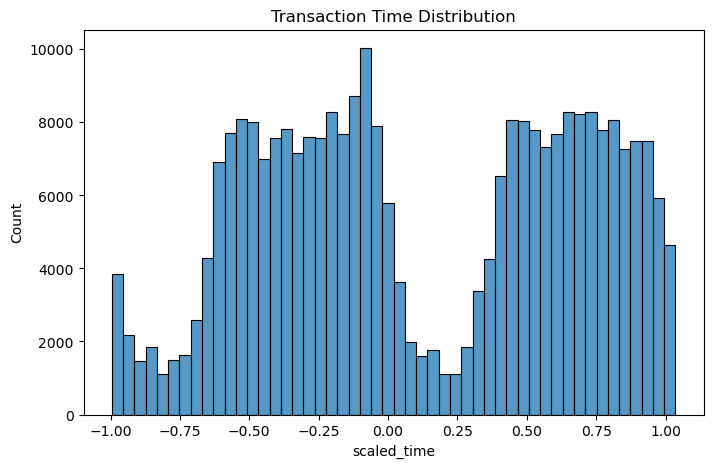

In [43]:
plt.figure(figsize=(8,5))
sb.histplot(df['scaled_time'], bins=50)
plt.title("Transaction Time Distribution")
plt.show()

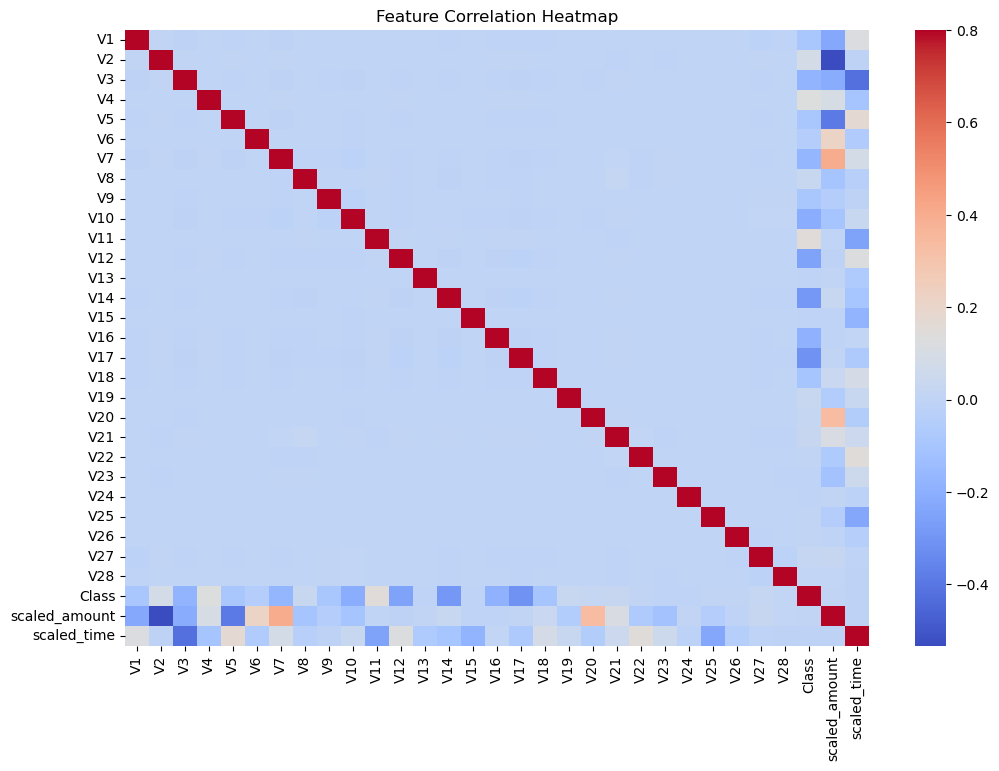

In [44]:
plt.figure(figsize=(12,8))
sb.heatmap(df.corr(), cmap='coolwarm', vmax=0.8)
plt.title("Feature Correlation Heatmap")
plt.show()

In [45]:
corr = df.corr()['Class'].sort_values(ascending=False)
print(corr.head(10))
print(corr.tail(10))

Class    1.000000
V11      0.149067
V4       0.129326
V2       0.084624
V19      0.033631
V8       0.033068
V21      0.026357
V27      0.021892
V20      0.021486
V28      0.009682
Name: Class, dtype: float64
V9    -0.094021
V1    -0.094486
V18   -0.105340
V7    -0.172347
V3    -0.182322
V16   -0.187186
V10   -0.206971
V12   -0.250711
V14   -0.293375
V17   -0.313498
Name: Class, dtype: float64


In [12]:
scaler = RobustScaler()

df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time']   = scaler.fit_transform(df[['Time']])

df = df.drop(['Amount','Time'], axis=1)

In [13]:
X = df.drop('Class', axis=1)
y = df['Class']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)

In [15]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print(y_train.value_counts())

Class
0    226602
1    226602
Name: count, dtype: int64


In [16]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [17]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=150,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=150, random_state=42)

In [25]:
pip install --user xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 3.0 MB/s eta 0:00:34
    --------------------------------------- 1.3/101.7 MB 3.2 MB/s eta 0:00:32
    --------------------------------------- 1.8/101.7 MB 3.2 MB/s eta 0:00:31
   - -------------------------------------- 2.6/101.7 MB 3.1 MB/s eta 0:00:32
   - -------------------------------------- 3.1/101.7 MB 3.2 MB/s eta 0:00:31
   - -------------------------------------- 3.7/101.7 MB 3.1 MB/s eta 0:00:32
   - -------------------------------------- 4.5/101.7 MB 3.0 MB/s eta 0:00:32
   - -------------------------------------- 4.7/101.7 MB 3.0 MB/s eta 0:00:33
   -- ------------------------------------- 5.2/101.7 MB 2.9 MB/s eta 0:00:34
   -- ------------------------------------- 5.8/101.7 MB 2.8 MB/s eta 0:00:34
   -- ------------------------------------- 6.3/101.7 MB 2.8 MB/s eta 0:00:34
   -- ------------------------------------- 7.1/101.7 MB 2.8 MB/s eta 0

In [26]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [27]:
from sklearn.metrics import classification_report, roc_auc_score

def evaluate(model):  
    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = (y_prob > 0.2).astype(int)
    print(model.__class__.__name__)
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("--------------------------------------------------")

In [28]:
evaluate(lr)
evaluate(rf)
evaluate(xgb)

LogisticRegression
              precision    recall  f1-score   support

           0       1.00      0.91      0.95     56651
           1       0.02      0.91      0.03        95

    accuracy                           0.91     56746
   macro avg       0.51      0.91      0.49     56746
weighted avg       1.00      0.91      0.95     56746

ROC-AUC: 0.9600608155753277
--------------------------------------------------
RandomForestClassifier
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.70      0.82      0.75        95

    accuracy                           1.00     56746
   macro avg       0.85      0.91      0.88     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9615956981295447
--------------------------------------------------
XGBClassifier
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.58

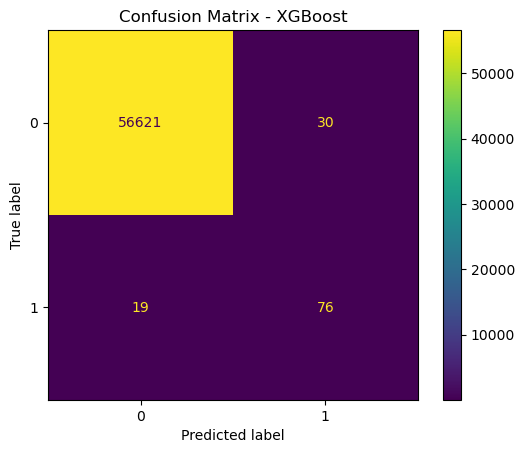

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test)
plt.title("Confusion Matrix - XGBoost")
plt.show()

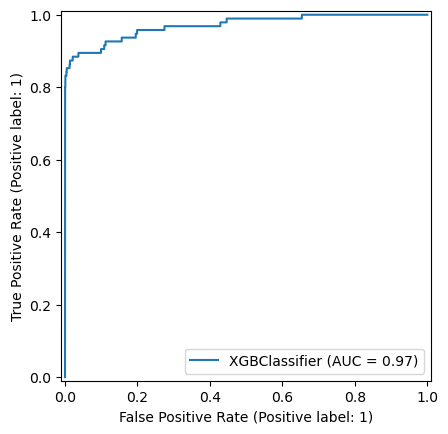

In [30]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(xgb, X_test, y_test)
plt.show()

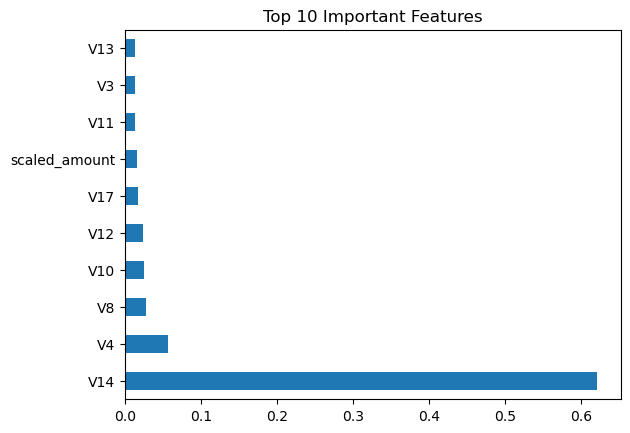

In [31]:
importance = pd.Series(xgb.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

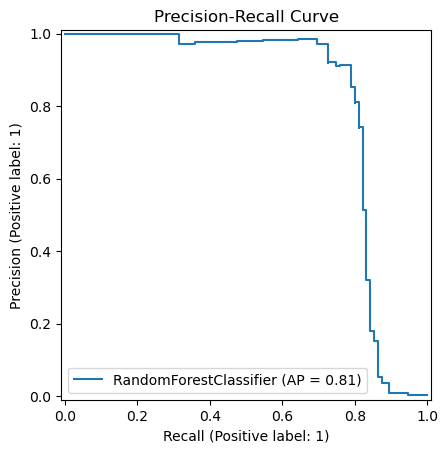

In [47]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_estimator(rf, X_test, y_test)
plt.title("Precision-Recall Curve")
plt.show()     

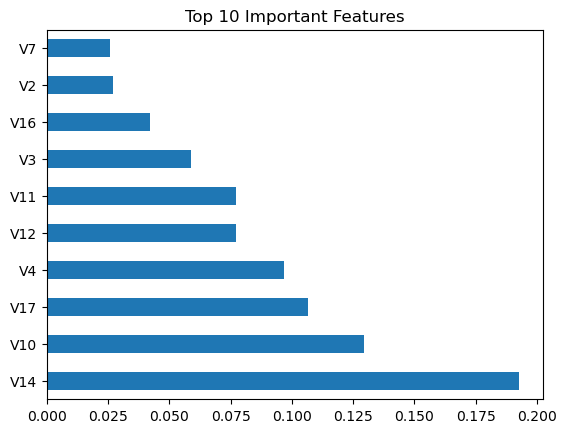

In [48]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

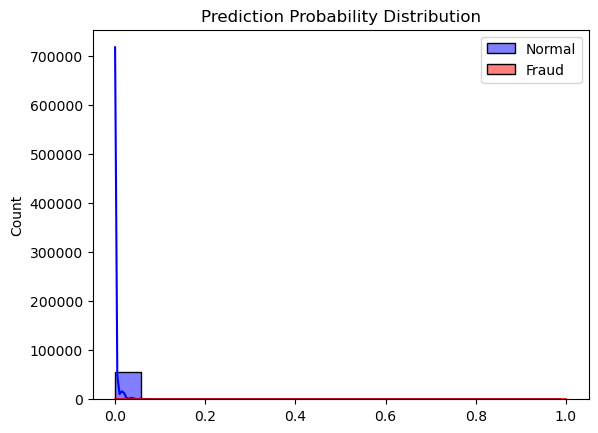

In [49]:
y_prob = rf.predict_proba(X_test)[:,1]
sb.histplot(y_prob[y_test==0], color='blue', label='Normal', kde=True)
sb.histplot(y_prob[y_test==1], color='red', label='Fraud', kde=True)
plt.legend()
plt.title("Prediction Probability Distribution")
plt.show()